In [1]:
!pip install folium pandas
!pip install shapely

In [2]:
import boto3
import pandas as pd
import io
from botocore.exceptions import ClientError
from shapely.geometry import Point, Polygon
import math
import folium
from folium import plugins
import numpy as np
import folium
import pandas as pd
from typing import Optional, Union, Tuple
import json
from ipywidgets import interact, FloatSlider, Layout
import ipywidgets as widgets
from shapely.vectorized import contains
import s3fs
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Initialize boto3 session and get credentials
session = boto3.Session()
credentials = session.get_credentials()

# Initialize S3 filesystem with boto3 credentials
s3 = s3fs.S3FileSystem(
    key=credentials.access_key,
    secret=credentials.secret_key,
    token=credentials.token,  # This will be included if using temporary credentials
    anon=False
)
# Read the parquet file
s3_path = 's3://birdsbucker/Cleaned_20250718/station_aggregated.parquet'
df_birds = pd.read_parquet(s3_path, filesystem=s3)

df_birds.head()

OBSERVATION_COUNT  \
assigned_station year_record month_record day_record                      
030209           2020        1            1                       232.0   
                                          2                        82.0   
                                          3                        49.0   
                                          4                        23.0   
                                          5                        85.0   

                                                              COMMON_NAME  \
assigned_station year_record month_record day_record                        
030209           2020        1            1                 American Crow   
                                          2                 American Crow   
                                          3            American Goldfinch   
                                          4           American Black Duck   
                                          5               Dark-eyed Junco   

                                                       LATITUDE  LONGITUDE  \
assigned_station year_record month_record day_record                         
030209           2020        1            1           44.749889 -68.773777   
                                          2           44.731871 -68.769746   
                                          3           44.751121 -68.781881   
                                          4           44.744680 -68.778359   
                                          5           44.729001 -68.783954   

                                                      i95_distance  \
assigned_station year_record month_record day_record                 
030209           2020        1            1               1.910628   
                                          2               2.705724   
                                          3               1.521868   
                                          4               1.895131   
                                          5               2.197516   

                                                     assigned_station_mode  \
assigned_station year_record month_record day_record                         
030209           2020        1            1                         030209   
                                          2                         030209   
                                          3                         030209   
                                          4                         030209   
                                          5                         030209   

                                                      hour_started_mode  \
assigned_station year_record month_record day_record                      
030209           2020        1            1                         7.0   
                                          2                         9.0   
                                          3                         7.0   
                                          4                         7.0   
                                          5                         7.0   

                                                      is_weekend  \
assigned_station year_record month_record day_record               
030209           2020        1            1                  0.0   
                                          2                  0.0   
                                          3                  1.0   
                                          4                  1.0   
                                          5                  1.0   

                                                      is_migration  \
assigned_station year_record month_record day_record                 
030209           2020        1            1                    0.0   
                                          2                    0.0   
                                          3                    0.0   
                                          4       

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import PowerTransformer
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

In [6]:
df_birds.shape

(22735, 15)

In [7]:
df_birds.columns

Index(['OBSERVATION_COUNT', 'COMMON_NAME', 'LATITUDE', 'LONGITUDE',
       'i95_distance', 'assigned_station_mode', 'hour_started_mode',
       'is_weekend', 'is_migration', 'extreme_weather', 'daily_avg_noise',
       'peak_hour_noise', 'overnight_noise', 'total_daily_volume',
       'eight_am_noise'],
      dtype='object')

## Calculating Baseline

### All Data

In [12]:
# Select features
y = np.log1p(df_birds['OBSERVATION_COUNT'])
X = df_birds[['assigned_station_mode', 'eight_am_noise']]

# Encode categorical variables if present
le = LabelEncoder()
if X['assigned_station_mode'].dtype == 'object':
    X.loc[:, 'assigned_station_mode'] = le.fit_transform(X['assigned_station_mode'])

# Split the data into train, validation, and test sets (60-20-20 split)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [16]:
X_val.head()

,,,,assigned_station_mode,eight_am_noise
assigned_station,year_record,month_record,day_record,,
040101,2022,1,19,3,91.746951
060164,2020,5,24,21,88.024265
053902,2022,5,19,17,87.462587
050910,2021,8,29,7,80.224960
052104,2023,6,26,11,84.495702


In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def calculate_baseline_metrics(X_train, y_train, X_val, y_val, X_test, y_test):
    # Create temporary dataframes combining features and target
    train_df = X_train.copy()
    train_df['OBSERVATION_COUNT'] = y_train
    
    val_df = X_val.copy()
    val_df['OBSERVATION_COUNT'] = y_val
    
    test_df = X_test.copy()
    test_df['OBSERVATION_COUNT'] = y_test
    
    # Calculate baseline prediction (mean of OBSERVATION_COUNT grouped by assigned_station)
    baseline_predictions = train_df.groupby('assigned_station_mode')['OBSERVATION_COUNT'].mean()
    
    # Function to map predictions to the dataset
    def get_predictions(df):
        return df['assigned_station_mode'].map(baseline_predictions).fillna(y_train.mean())
    
    # Generate predictions for validation and test sets
    val_predictions = get_predictions(val_df)
    test_predictions = get_predictions(test_df)
    
    # Calculate metrics
    metrics = {
        'Validation R2': r2_score(y_val, val_predictions),
        'Test R2': r2_score(y_test, test_predictions),
        'Validation RMSE': np.sqrt(mean_squared_error(y_val, val_predictions)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_predictions)),
        'Validation MAE': mean_absolute_error(y_val, val_predictions),
        'Test MAE': mean_absolute_error(y_test, test_predictions)
    }
    
    return metrics, val_predictions, test_predictions

# Run the function with your data
metrics, val_predictions, test_predictions = calculate_baseline_metrics(
    X_train, y_train, X_val, y_val, X_test, y_test
)

# Print the metrics
print("\nBaseline Model Metrics:")
print("-" * 50)
for metric_name, value in metrics.items():
    print(f"{metric_name}: {value:.4f}")

# Optional: Display some basic statistics about the predictions
print("\nPrediction Statistics:")
print("-" * 50)
print("\nValidation Predictions:")
print(pd.Series(val_predictions).describe())
print("\nTest Predictions:")
print(pd.Series(test_predictions).describe())

# Optional: You might want to save the predictions for later comparison
val_results = pd.DataFrame({
    'Actual': y_val,
    'Predicted': val_predictions,
    'Error': y_val - val_predictions
})

test_results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': test_predictions,
    'Error': y_test - test_predictions
})

# Print sample of results
print("\nSample of Validation Results:")
print("-" * 50)
print(val_results.head())


Baseline Model Metrics:
--------------------------------------------------
Validation R2: 0.0656
Test R2: 0.0775
Validation RMSE: 1.2325
Test RMSE: 1.2592
Validation MAE: 0.9949
Test MAE: 1.0103

Prediction Statistics:
--------------------------------------------------

Validation Predictions:
count    1793.000000
mean        3.181703
std         0.363947
min         1.547904
25%         3.063723
50%         3.294316
75%         3.491456
max         3.735428
Name: assigned_station_mode, dtype: float64

Test Predictions:
count    1793.000000
mean        3.173640
std         0.360756
min         1.547904
25%         2.991636
50%         3.294316
75%         3.491456
max         3.735428
Name: assigned_station_mode, dtype: float64

Sample of Validation Results:
--------------------------------------------------
                                                        Actual  Predicted  \
assigned_station year_record month_record day_record                        
040101           2022    

### 8AM data

## Modeling

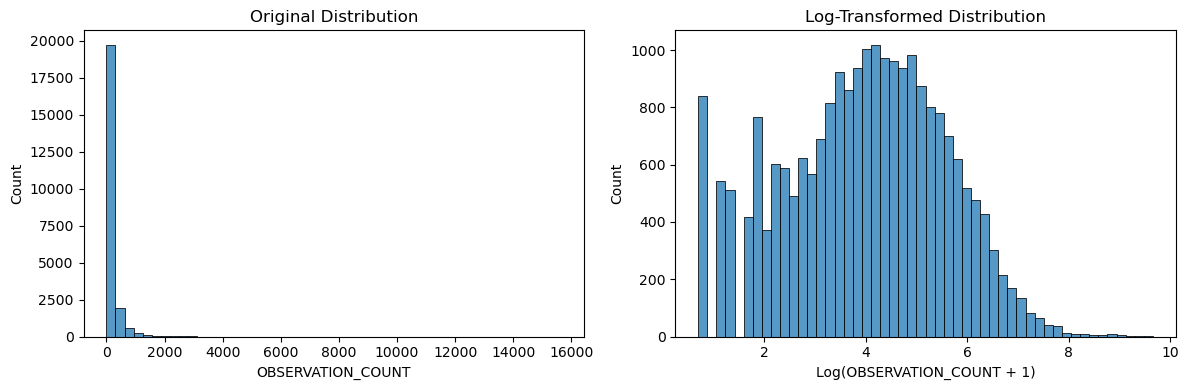

In [8]:

# Visualize the original distribution
plt.figure(figsize=(12, 4))
plt.subplot(121)
sns.histplot(df_birds['OBSERVATION_COUNT'], bins=50)
plt.title('Original Distribution')
plt.xlabel('OBSERVATION_COUNT')

# Apply log transformation to handle skewness
# Adding 1 before log to handle zero values
y = np.log1p(df_birds['OBSERVATION_COUNT'])

plt.subplot(122)
sns.histplot(y, bins=50)
plt.title('Log-Transformed Distribution')
plt.xlabel('Log(OBSERVATION_COUNT + 1)')
plt.tight_layout()
plt.show()

In [9]:
# Select features
X = df_birds[['assigned_station_mode', 'eight_am_noise']]

# Encode categorical variables if present
le = LabelEncoder()
if X['assigned_station_mode'].dtype == 'object':
    X.loc[:, 'assigned_station_mode'] = le.fit_transform(X['assigned_station_mode'])

# Split the data into train, validation, and test sets (60-20-20 split)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Initialize and train the base model
base_model = GradientBoostingRegressor(random_state=42)
base_model.fit(X_train, y_train)

# Modified evaluation function to handle log-transformed data
def evaluate_model(model, X, y, dataset_name):
    predictions = model.predict(X)
    
    # Calculate metrics on log scale
    mse_log = mean_squared_error(y, predictions)
    rmse_log = np.sqrt(mse_log)
    r2_log = r2_score(y, predictions)
    
    # Transform predictions back to original scale
    predictions_original = np.expm1(predictions)
    y_original = np.expm1(y)
    
    # Calculate metrics on original scale
    mse_original = mean_squared_error(y_original, predictions_original)
    rmse_original = np.sqrt(mse_original)
    r2_original = r2_score(y_original, predictions_original)
    
    print(f"{dataset_name} Results:")
    print(f"Log Scale - RMSE: {rmse_log:.4f}, R2 Score: {r2_log:.4f}")
    print(f"Original Scale - RMSE: {rmse_original:.4f}, R2 Score: {r2_original:.4f}\n")

# Evaluate base model
print("Base Model Performance:")
evaluate_model(base_model, X_train, y_train, "Training")
evaluate_model(base_model, X_val, y_val, "Validation")
evaluate_model(base_model, X_test, y_test, "Test")



Base Model Performance:
Training Results:
Log Scale - RMSE: 1.2141, R2 Score: 0.4218
Original Scale - RMSE: 421.2907, R2 Score: 0.0261

Validation Results:
Log Scale - RMSE: 1.2324, R2 Score: 0.4060
Original Scale - RMSE: 346.9374, R2 Score: 0.0402

Test Results:
Log Scale - RMSE: 1.2076, R2 Score: 0.4167
Original Scale - RMSE: 292.0490, R2 Score: 0.0546



In [10]:
# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 0.9, 1.0]  # Added subsample parameter to help with skewness
}

# Perform GridSearchCV
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Print best parameters and score
print("\nBest Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score (RMSE):", np.sqrt(-grid_search.best_score_))

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate the best model
print("\nBest Model Performance:")
evaluate_model(best_model, X_train, y_train, "Training")
evaluate_model(best_model, X_val, y_val, "Validation")
evaluate_model(best_model, X_test, y_test, "Test")

# Save the best model and the label encoder
model_artifacts = {
    'model': best_model,
    'label_encoder': le,
    'log_transform': True  # Flag to indicate log transformation was used
}
joblib.dump(model_artifacts, 'best_gradient_boosting_model.joblib')



Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 0.8}
Best Cross-Validation Score (RMSE): 1.226470615972244

Best Model Performance:
Training Results:
Log Scale - RMSE: 1.1936, R2 Score: 0.4412
Original Scale - RMSE: 418.8659, R2 Score: 0.0373

Validation Results:
Log Scale - RMSE: 1.2327, R2 Score: 0.4058
Original Scale - RMSE: 345.7788, R2 Score: 0.0466

Test Results:
Log Scale - RMSE: 1.2091, R2 Score: 0.4153
Original Scale - RMSE: 291.1639, R2 Score: 0.0603



['best_gradient_boosting_model.joblib']


Feature Importance:
                 feature  importance
0  assigned_station_mode    0.552829
1         eight_am_noise    0.447171


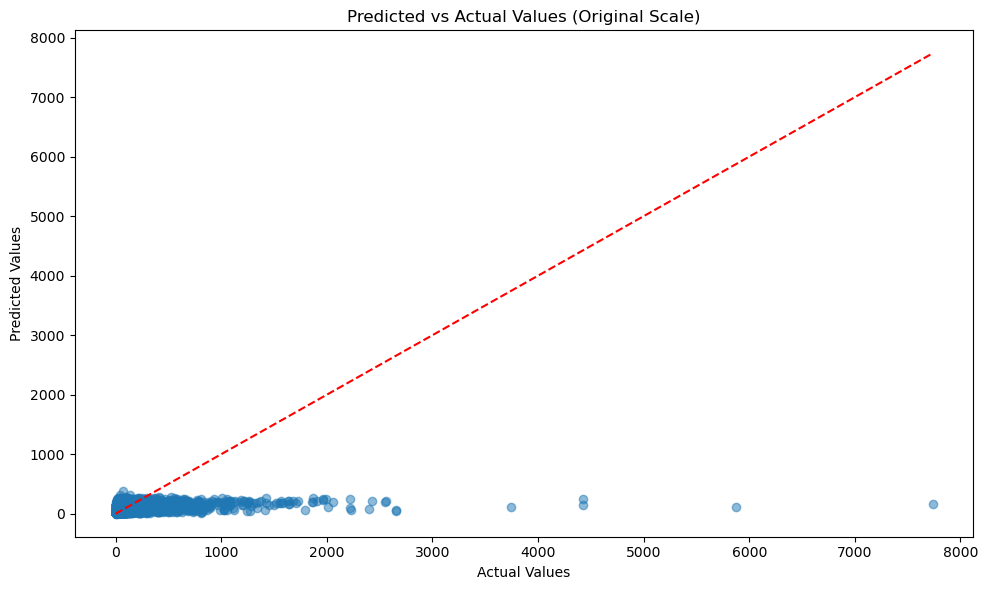

In [11]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
})
print("\nFeature Importance:")
print(feature_importance.sort_values('importance', ascending=False))

# Visualize predictions vs actual values
plt.figure(figsize=(10, 6))
y_pred = best_model.predict(X_test)
plt.scatter(np.expm1(y_test), np.expm1(y_pred), alpha=0.5)
plt.plot([0, np.expm1(y_test).max()], [0, np.expm1(y_test).max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values (Original Scale)')
plt.tight_layout()
plt.show()

In [ ]:
# Function to make new predictions
def predict_new_data(model_artifacts, new_data):
    """
    Make predictions on new data using the saved model
    
    Parameters:
    model_artifacts: dict with model and preprocessing objects
    new_data: DataFrame with the same features used during training
    """
    model = model_artifacts['model']
    le = model_artifacts['label_encoder']
    
    # Preprocess new data
    if 'assigned_station_mode' in new_data.columns and new_data['assigned_station_mode'].dtype == 'object':
        new_data['assigned_station_mode'] = le.transform(new_data['assigned_station_mode'])
    
    # Make predictions
    predictions_log = model.predict(new_data)
    
    # Transform predictions back to original scale
    predictions_original = np.expm1(predictions_log)
    
    return predictions_original

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.linear_model import ElasticNet
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor
# from sklearn.model_selection import RandomizedSearchCV
# import optuna
# import matplotlib.pyplot as plt
# import seaborn as sns

# class PredictiveModel:
#     def __init__(self, df, target='OBSERVATION_COUNT', test_size=0.2, val_size=0.25):
#         self.df = df
#         self.target = target
#         self.test_size = test_size
#         self.val_size = val_size
#         self.models = {}
#         self.best_model = None
#         self.best_score = float('-inf')
        
#     def prepare_data(self):
#         # Create feature matrix X and target vector y
#         X = self.df.drop(columns=[self.target])
#         y = self.df[self.target]
        
#         # Encode categorical variables
#         le = LabelEncoder()
#         X['assigned_station'] = le.fit_transform(X['assigned_station'])
        
#         # Split into train, validation, and test sets
#         X_train_val, self.X_test, y_train_val, self.y_test = train_test_split(
#             X, y, test_size=self.test_size, random_state=42
#         )
        
#         self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
#             X_train_val, y_train_val, test_size=self.val_size, random_state=42
#         )
        
#         # Scale features
#         scaler = StandardScaler()
#         self.X_train_scaled = scaler.fit_transform(self.X_train)
#         self.X_val_scaled = scaler.transform(self.X_val)
#         self.X_test_scaled = scaler.transform(self.X_test)
        
#         # Store feature names
#         self.feature_names = X.columns
        
#         print("Data split sizes:")
#         print(f"Training set: {self.X_train.shape[0]} samples")
#         print(f"Validation set: {self.X_val.shape[0]} samples")
#         print(f"Test set: {self.X_test.shape[0]} samples")

#     def objective_rf(self, trial):
#         params = {
#             'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#             'max_depth': trial.suggest_int('max_depth', 3, 30),
#             'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
#             'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
#         }
#         model = RandomForestRegressor(**params, random_state=42)
#         model.fit(self.X_train_scaled, self.y_train)
#         predictions = model.predict(self.X_val_scaled)
#         return r2_score(self.y_val, predictions)

#     def objective_xgb(self, trial):
#         params = {
#             'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#             'max_depth': trial.suggest_int('max_depth', 3, 30),
#             'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#             'subsample': trial.suggest_float('subsample', 0.5, 1.0)
#         }
#         model = XGBRegressor(**params, random_state=42)
#         model.fit(self.X_train_scaled, self.y_train)
#         predictions = model.predict(self.X_val_scaled)
#         return r2_score(self.y_val, predictions)

#     def objective_lgbm(self, trial):
#         params = {
#             'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#             'max_depth': trial.suggest_int('max_depth', 3, 30),
#             'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#             'num_leaves': trial.suggest_int('num_leaves', 20, 100)
#         }
#         model = LGBMRegressor(**params, random_state=42)
#         model.fit(self.X_train_scaled, self.y_train)
#         predictions = model.predict(self.X_val_scaled)
#         return r2_score(self.y_val, predictions)

#     def train_models(self, n_trials=100):
#         # Dictionary to store study results
#         self.studies = {}
        
#         # Train Random Forest
#         study_rf = optuna.create_study(direction='maximize')
#         study_rf.optimize(self.objective_rf, n_trials=n_trials)
#         self.models['Random Forest'] = RandomForestRegressor(**study_rf.best_params, random_state=42)
#         self.studies['Random Forest'] = study_rf

#         # Train XGBoost
#         study_xgb = optuna.create_study(direction='maximize')
#         study_xgb.optimize(self.objective_xgb, n_trials=n_trials)
#         self.models['XGBoost'] = XGBRegressor(**study_xgb.best_params, random_state=42)
#         self.studies['XGBoost'] = study_xgb

#         # Train LightGBM
#         study_lgbm = optuna.create_study(direction='maximize')
#         study_lgbm.optimize(self.objective_lgbm, n_trials=n_trials)
#         self.models['LightGBM'] = LGBMRegressor(**study_lgbm.best_params, random_state=42)
#         self.studies['LightGBM'] = study_lgbm

#         # Train and evaluate all models
#         results = []
#         for name, model in self.models.items():
#             # Train the model
#             model.fit(self.X_train_scaled, self.y_train)
            
#             # Make predictions on validation set
#             val_predictions = model.predict(self.X_val_scaled)
#             val_r2 = r2_score(self.y_val, val_predictions)
#             val_rmse = np.sqrt(mean_squared_error(self.y_val, val_predictions))
#             val_mae = mean_absolute_error(self.y_val, val_predictions)
            
#             results.append({
#                 'Model': name,
#                 'R2 Score': val_r2,
#                 'RMSE': val_rmse,
#                 'MAE': val_mae,
#                 'Best Parameters': self.studies[name].best_params
#             })
            
#             # Update best model
#             if val_r2 > self.best_score:
#                 self.best_score = val_r2
#                 self.best_model = model
        
#         self.results_df = pd.DataFrame(results)
#         print("\nModel Comparison on Validation Set:")
#         print(self.results_df)

#     def evaluate_best_model(self):
#         # Make predictions on test set
#         test_predictions = self.best_model.predict(self.X_test_scaled)
        
#         # Calculate metrics
#         test_r2 = r2_score(self.y_test, test_predictions)
#         test_rmse = np.sqrt(mean_squared_error(self.y_test, test_predictions))
#         test_mae = mean_absolute_error(self.y_test, test_predictions)
        
#         print("\nBest Model Performance on Test Set:")
#         print(f"R2 Score: {test_r2:.4f}")
#         print(f"RMSE: {test_rmse:.4f}")
#         print(f"MAE: {test_mae:.4f}")
        
#         # Plot actual vs predicted values
#         plt.figure(figsize=(10, 6))
#         plt.scatter(self.y_test, test_predictions, alpha=0.5)
#         plt.plot([self.y_test.min(), self.y_test.max()], 
#                  [self.y_test.min(), self.y_test.max()], 
#                  'r--', lw=2)
#         plt.xlabel('Actual OBSERVATION_COUNT')
#         plt.ylabel('Predicted OBSERVATION_COUNT')
#         plt.title('Actual vs Predicted Values (Test Set)')
#         plt.show()
        
#         # Feature importance for tree-based models
#         if hasattr(self.best_model, 'feature_importances_'):
#             importance = pd.DataFrame({
#                 'feature': self.feature_names,
#                 'importance': self.best_model.feature_importances_
#             }).sort_values('importance', ascending=False)
            
#             plt.figure(figsize=(10, 6))
#             sns.barplot(data=importance, x='importance', y='feature')
#             plt.title('Feature Importance')
#             plt.show()

# # Use the model
# model = PredictiveModel(synthetic_df)
# model.prepare_data()
# model.train_models(n_trials=50)  # Reduced trials for demonstration
# model.evaluate_best_model()

# # Save the best model (optional)
# import joblib
# joblib.dump(model.best_model, 'best_model.joblib')